# Pipeline execution for a single record (1 subject, 1 condition, 1 stimulus)

This pipeline runs the four processing modules (`loading`, `filtering`, `peak_detection`,
`hr_analysis`) on the pilot recording(sub-01) and reproduces the diagnostic figures
used to validate each step: raw signal, filtering effect, R-peak detection,
instantaneous HR and interpolation.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from loading import load_ecg
from filtering import highpass_filter, notch_filter
from peak_detection import detect_r_peaks
from hr_analysis import instantaneous_hr, interpolate_hr

TSV = 'data/sub-01/ses-01/beh/sub-01_ses-01_task-stim01_recording-ecg_physio.tsv.gz'
JSON = 'data/sub-01/ses-01/beh/sub-01_ses-01_task-stim01_recording-ecg_physio.json'

## Raw signal

This section reads the raw ECG samples from the .tsv.gz data file and the metadata from its .json
sidecar, returning three things: the raw signal array (raw), the sampling frequency (fs), and a
human-readable condition label. 
The line t = np.arange(len(raw)) / fs builds a time axis in
seconds by dividing each sample index by the sampling frequency. 

After that, it plots the raw signal twice: the full recording (top) and a 5-second zoom (bottom),
obtained with the boolean mask t < 5 which selects only the samples whose timestamp is below
5 seconds.

Output: the recording is 23.651 samples long at 128 Hz, which corresponds to
23,651/128 ≈ 184.8 seconds of dat. 
The condition label confirms we loaded the correct file (stimulus 01, Attentive session).

Stim 01, Attentive Condition 128 Hz 23651 samples


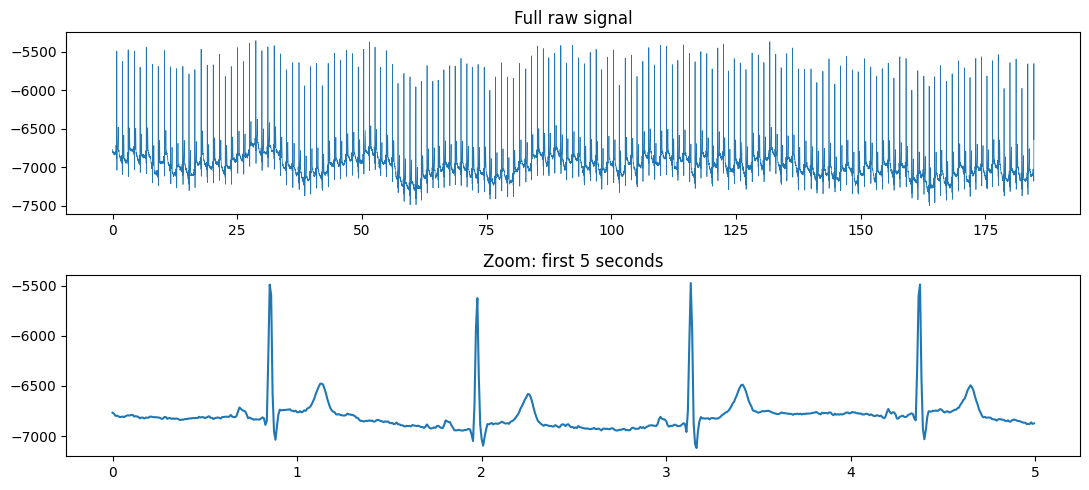

In [5]:
raw, fs, condition = load_ecg(TSV, JSON)
t = np.arange(len(raw)) / fs
print(condition, fs, 'Hz', len(raw), 'samples')

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
axes[0].plot(t, raw, linewidth=0.5)
axes[0].set_title('Full raw signal')
mask = t < 5
axes[1].plot(t[mask], raw[mask])
axes[1].set_title('Zoom: first 5 seconds')
plt.tight_layout()
plt.show()

## Filtering: high-pass removes the DC offset, notch has marginal effect at 128 Hz

This section applies the two filtering stages in sequence: first the (highpass filte), then the 60 Hz(notch filte) on top of the highpass output.
 Th 
three-panel plot shows the same 10-second window at each sta from raw signal to notch(highpass) filteredg

The highpass stage removes the baseline offset: the signal is now 
centred on zero, while the shape of each heartbeat is preserved. The notch stag) is
visually indistinguishable from the highpass-only sign, so confirming on real data that 60 Hz z
notch has a marginal effect at this sampling rate (60 Hz sits just below the 64 Hz Nyquist li)ithere.e.

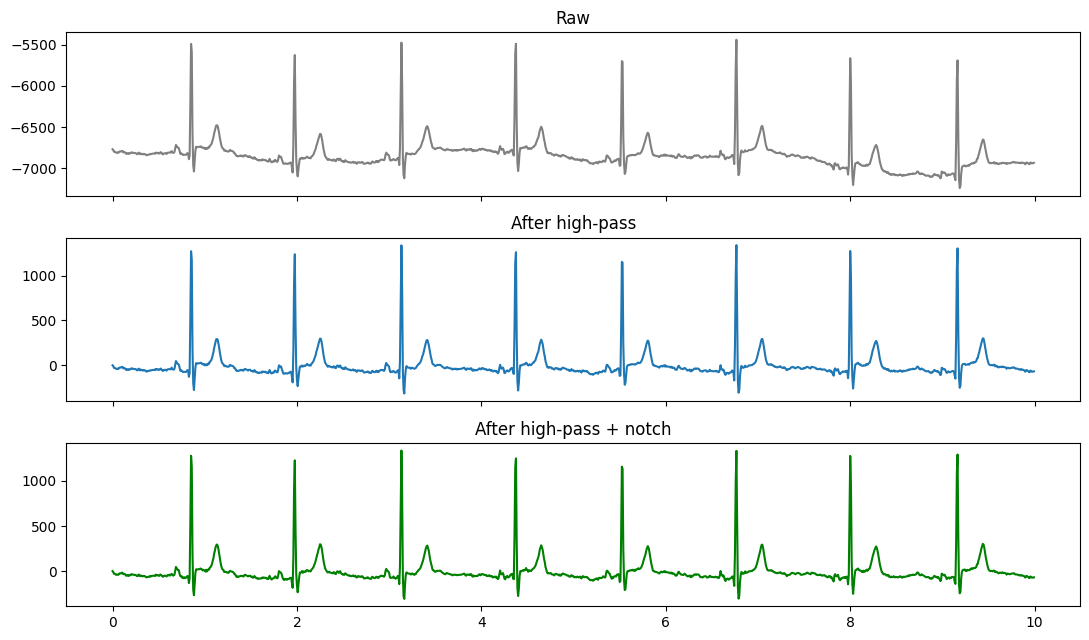

In [8]:
hp = highpass_filter(raw, fs)
filtered = notch_filter(hp, fs)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
mask = t < 10
axes[0].plot(t[mask], raw[mask], color='gray'); axes[0].set_title('Raw')
axes[1].plot(t[mask], hp[mask]); axes[1].set_title('After high-pass')
axes[2].plot(t[mask], filtered[mask], color='green'); axes[2].set_title('After high-pass + notch')
plt.tight_layout()
plt.show()

## R-peak detection: visual check

This section will detect r peaks on the filtered signal, which returns the sample indices 
of the detected peaks and the amplitude threshold actually used.

The plot overlays the detected
peaks (red dots) on the first 15 seconds of the filtered signal; pm = peaks[t[peaks] < 15] selects
only the peaks falling within that windo


Output: 157 peaks were detected over the whole recording, using an adaptive 
threshold of 498.6 mV (computed as 3× the signal’s standard deviation).Tthe two-criterion algorithm (amplitude threshold plus 0.3 s minimu 
spacing) is working correctlte.k.
ow.

157 peaks detected, amplitude threshold = 498.6 a.u.


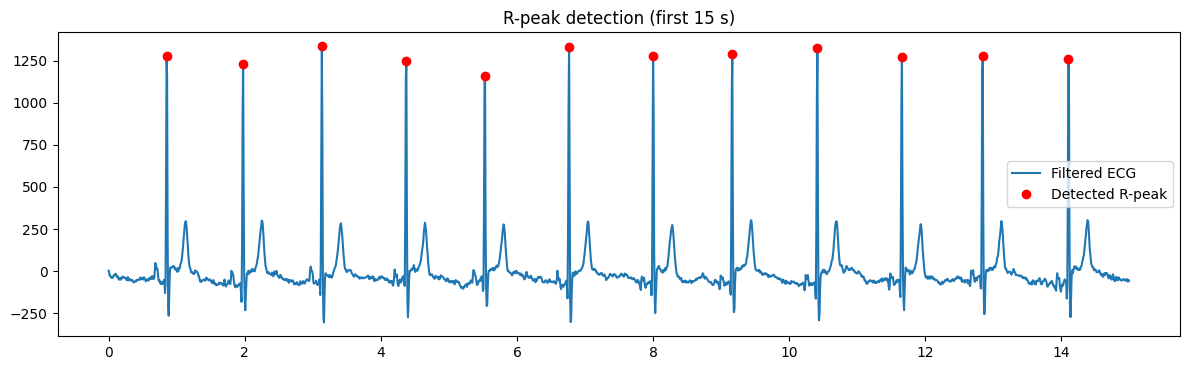

In [9]:
peaks, threshold = detect_r_peaks(filtered, fs)
print(f'{len(peaks)} peaks detected, amplitude threshold = {threshold:.1f} a.u.')

fig, ax = plt.subplots(figsize=(12, 3.8))
mask = t < 15
ax.plot(t[mask], filtered[mask], label='Filtered ECG')
pm = peaks[t[peaks] < 15]
ax.plot(t[pm], filtered[pm], 'o', color='red', label='Detected R-peak')
ax.legend(); ax.set_title('R-peak detection (first 15 s)')
plt.tight_layout()
plt.show()

## Instantaneous HR and interpolation onto a common grid

This section converts the peak indices into an instantaneous HR series (instantaneous hr), 
then resamples that irregular series onto a regular 4 Hz grid (interpolate hr).

 The plot show 
both: the raw beat-to-beat values as red dots (irregularly spaced, one per beat), and thicinterpolat d
signal as a continuous blue line on the uniform g.

Output: The mean instantaneous HR is 51.0 BPM with a standard deviation of 
2.2 BP. 
. The interpolated line follows the irregular points faithfulact, confirming the resampling correctunnote.ridcy.

Mean HR: 51.0 BPM (std 2.2)


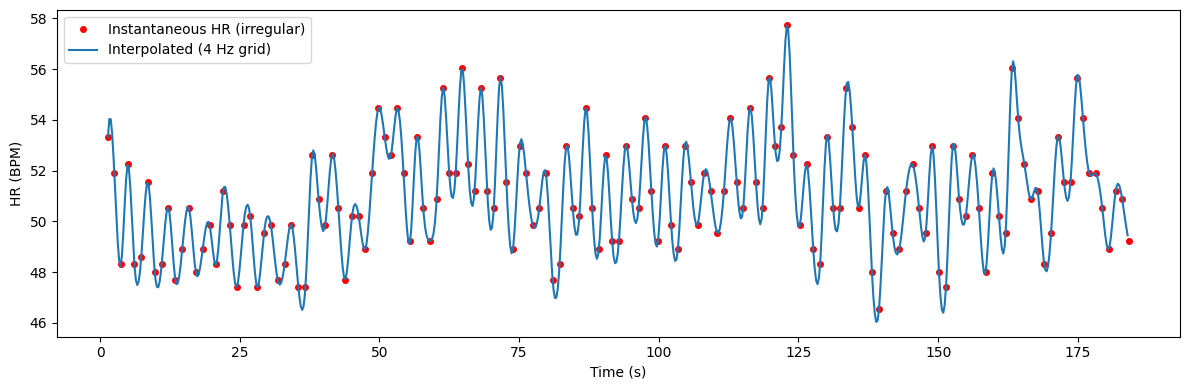

In [10]:
t_hr, hr, rr = instantaneous_hr(peaks, fs)
t_common, hr_interp = interpolate_hr(t_hr, hr, fs_common=4.0)
print(f'Mean HR: {hr.mean():.1f} BPM (std {hr.std():.1f})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_hr, hr, 'o', color='red', markersize=4, label='Instantaneous HR (irregular)')
ax.plot(t_common, hr_interp, '-', label='Interpolated (4 Hz grid)')
ax.legend(); ax.set_xlabel('Time (s)'); ax.set_ylabel('HR (BPM)')
plt.tight_layout()
plt.show()